
┌──────────────────────────────────────────────────────────────┐
│  ORTAM BİLGİSİ                                               │
└──────────────────────────────────────────────────────────────┘
  Cihaz   : CUDA
  PyTorch : 2.10.0+cu130
  CUDA    : 13.0


c:\Users\Fatih\Desktop\Qwen\dogru\Lib\site-packages\torchvision\datasets\cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")



┌──────────────────────────────────────────────────────────────┐
│  AŞAMA 1 ▸ BASELINE  (Adaptasyon Yok)                        │
└──────────────────────────────────────────────────────────────┘


  Baseline: 100%|██████████████████████████████| 50/50 [00:00<00:00, 91.66it/s, Doğruluk=%14.06]



  ● Baseline Ortalama Doğruluk : %12.12

┌──────────────────────────────────────────────────────────────┐
│  AŞAMA 2 ▸ TENT  (Çevrimiçi Adaptasyon — Etiketsiz)          │
└──────────────────────────────────────────────────────────────┘


  TENT   : 100%|██████████████████████████████| 50/50 [00:00<00:00, 51.25it/s, Entropi=0.4640, Doğruluk=%35.94]
C:\Users\Fatih\AppData\Local\Temp\ipykernel_15008\3059033746.py:366: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()
C:\Users\Fatih\AppData\Local\Temp\ipykernel_15008\3059033746.py:368: UserWarning: Glyph 9312 (\N{CIRCLED DIGIT ONE}) missing from font(s) Arial.
  plt.savefig(out, dpi=300, bbox_inches="tight", facecolor=FIG_BG)
C:\Users\Fatih\AppData\Local\Temp\ipykernel_15008\3059033746.py:368: UserWarning: Glyph 9313 (\N{CIRCLED DIGIT TWO}) missing from font(s) Arial.
  plt.savefig(out, dpi=300, bbox_inches="tight", facecolor=FIG_BG)
C:\Users\Fatih\AppData\Local\Temp\ipykernel_15008\3059033746.py:368: UserWarning: Glyph 9314 (\N{CIRCLED DIGIT THREE}) missing from font(s) Arial.
  plt.savefig(out, dpi=300, bbox_inches="tight", facecolor=FIG_BG)



  ● TENT Ortalama Doğruluk     : %29.09


╔══════════════════════════════════════════════════════════════╗
║          TEST-TIME ADAPTATION  ·  ANALİZ RAPORU             ║
╚══════════════════════════════════════════════════════════════╝

  Deney Kurulumu
  ├─ Model     : ResNet-56  (CIFAR-10 pretrained)
  ├─ Bozulma   : Gaussian Gürültüsü  σ = 0.25
  ├─ Batch     : 64 örnek  ×  50 iterasyon
  └─ Optimize  : Adam  (lr = 0.001)

  📊 Performans Karşılaştırması
  ├─ Baseline (Adaptasyon Yok)  : % 12.12
  ├─ TENT     (Online Adapt.)   : % 29.09
  ├─ Mutlak İyileşme            : +%16.97
  └─ Göreceli İyileşme          : +%139.95

  📉 Entropi Analizi  H(p) = −Σ p·log(p)
  ├─ Başlangıç Entropisi        : 0.6780
  ├─ Bitiş Entropisi            : 0.4640
  ├─ Düşüş Miktarı             : 0.2141
  └─ Sonuç                      : ✅  Başarıyla minimize edildi

  ─────────────────────────────────────────────────────────────
  Kaynak: Wang et al., "Tent: Fully Test-Time Adaptation by
           Entropy

c:\Users\Fatih\Desktop\Qwen\dogru\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 9312 (\N{CIRCLED DIGIT ONE}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\Fatih\Desktop\Qwen\dogru\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 9313 (\N{CIRCLED DIGIT TWO}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\Fatih\Desktop\Qwen\dogru\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 9314 (\N{CIRCLED DIGIT THREE}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


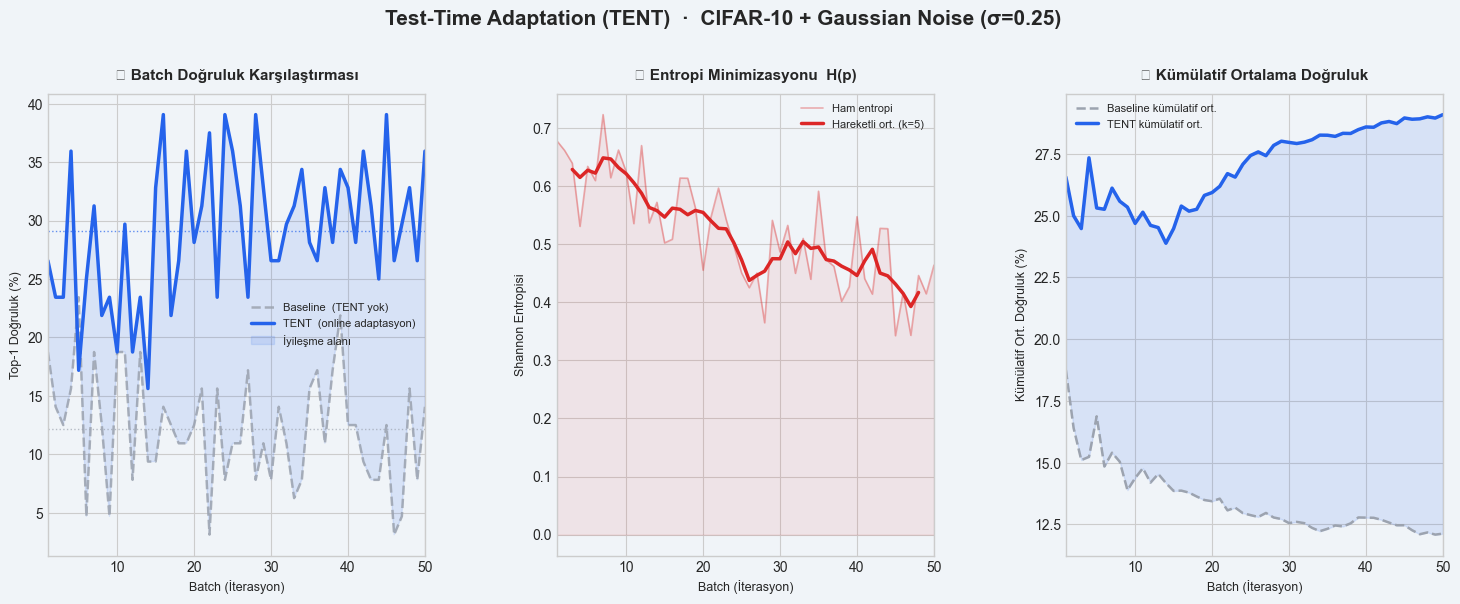

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# KÜTÜPHANELER
# ─────────────────────────────────────────────────────────────────────────────
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np
from tqdm import tqdm
from torch.amp import GradScaler

# ─────────────────────────────────────────────────────────────────────────────
# TERMINAL RENK KODLARI  (Windows'ta çalışmıyorsa colorama kurulabilir)
# ─────────────────────────────────────────────────────────────────────────────
class C:
    HEADER  = "\033[95m"
    BLUE    = "\033[94m"
    CYAN    = "\033[96m"
    GREEN   = "\033[92m"
    YELLOW  = "\033[93m"
    RED     = "\033[91m"
    BOLD    = "\033[1m"
    DIM     = "\033[2m"
    RESET   = "\033[0m"

def banner(title: str, color: str = C.CYAN) -> None:
    """Başlık kutucuğu yazdıran yardımcı fonksiyon."""
    line = "─" * 62
    print(f"\n{color}{C.BOLD}┌{line}┐")
    print(f"│  {title:<60}│")
    print(f"└{line}┘{C.RESET}")

# ─────────────────────────────────────────────────────────────────────────────
# HİPER-PARAMETRELER
# ─────────────────────────────────────────────────────────────────────────────
DEVICE         = "cuda" if torch.cuda.is_available() else "cpu"
LEARNING_RATE  = 1e-3
BATCH_SIZE     = 64
NUM_BATCHES    = 50          # Değerlendirilen toplam batch sayısı
NOISE_STD      = 0.25        # Gaussian gürültü standart sapması

CIFAR10_MEAN   = [0.4914, 0.4822, 0.4465]
CIFAR10_STD    = [0.2023, 0.1994, 0.2010]

# ─────────────────────────────────────────────────────────────────────────────
# BÖLÜM 1 — TENT ALGORİTMASININ ÇEKİRDEĞİ
# ─────────────────────────────────────────────────────────────────────────────

def setup_tent_model(model: nn.Module) -> nn.Module:
    """
    Tent için model hazırlığı.

    Strateji:
        1. Tüm parametreleri dondur (requires_grad=False).
        2. Yalnızca BatchNorm2d katmanlarındaki γ ve β'yı güncellemeye aç.
        3. BN katmanlarını train() moduna al (istatistik güncellenir).
        4. Diğer tüm katmanları eval() modunda tut.

    Neden sadece BN?
        • Az parametre → kararlı optimizasyon
        • BN istatistikleri dağılım kaymasına en duyarlı bileşendir
        • Gradyan patlaması / kaybı riski çok düşüktür
    """
    model.requires_grad_(False)                         # Önce hepsini dondur

    for module in model.modules():
        if isinstance(module, nn.BatchNorm2d):
            module.requires_grad_(True)                 # γ ve β'yı aç
            module.weight.requires_grad_(True)          # γ — scale
            module.bias.requires_grad_(True)            # β — shift
            module.train()                              # BN train modunda kalsın

    return model.to(DEVICE)


def entropy_loss(logits: torch.Tensor) -> torch.Tensor:
    """
    Shannon Entropisi: H(p) = −Σ p · log(p)

    • p → softmax çıktısı (sınıf olasılık dağılımı)
    • Düşük entropi ↔ modelin emin, net tahmini
    • Yüksek entropi ↔ dağılım kaymasından kaynaklanan belirsizlik

    Gradyan ile minimize edilerek BN parametreleri gürültülü dağılıma uyarlanır.
    """
    p     = torch.softmax(logits, dim=1)
    log_p = torch.log_softmax(logits, dim=1)
    return -(p * log_p).sum(dim=1).mean()

# ─────────────────────────────────────────────────────────────────────────────
# BÖLÜM 2 — VERİ SETİ  (Gaussian Gürültüsü ile Dağılım Kayması Simülasyonu)
# ─────────────────────────────────────────────────────────────────────────────

class AddGaussianNoise:
    """
    Torchvision transform: tensöre Gaussian (Normal) gürültü ekler.

    Gerçek dünya senaryosu:
        Eğitim → temiz görüntüler
        Test   → sensör gürültüsü / atmosferik etki / sıkıştırma artefaktı
    """
    def __init__(self, mean: float = 0.0, std: float = 1.0):
        self.mean = mean
        self.std  = std

    def __call__(self, tensor: torch.Tensor) -> torch.Tensor:
        return tensor + torch.randn_like(tensor) * self.std + self.mean

    def __repr__(self) -> str:
        return f"AddGaussianNoise(mean={self.mean}, std={self.std})"


transform_bozulmus = transforms.Compose([
    transforms.ToTensor(),
    AddGaussianNoise(mean=0.0, std=NOISE_STD),      # ← Dağılım kayması buradan
    transforms.Normalize(mean=CIFAR10_MEAN, std=CIFAR10_STD),
])

# ─────────────────────────────────────────────────────────────────────────────
# BÖLÜM 3 — YARDIMCI FONKSİYONLAR
# ─────────────────────────────────────────────────────────────────────────────

def get_accuracy(outputs: torch.Tensor, labels: torch.Tensor) -> float:
    """Top-1 doğruluğu [0, 1] aralığında döndürür."""
    _, predicted = outputs.max(dim=1)
    return predicted.eq(labels).float().mean().item()


def load_pretrained() -> nn.Module:
    """CIFAR-10 için önceden eğitilmiş ResNet-56'yı yükler."""
    return torch.hub.load(
        "chenyaofo/pytorch-cifar-models",
        "cifar10_resnet56",
        pretrained=True,
        verbose=False,
    )

# ─────────────────────────────────────────────────────────────────────────────
# BÖLÜM 4 — AŞAMA 1: BASELINE DEĞERLENDİRME  (adaptasyon yok)
# ─────────────────────────────────────────────────────────────────────────────

def evaluate_baseline(testloader) -> list[float]:
    """
    Standart çıkarım (inference): model parametreleri tamamen dondurulmuş,
    gradyan hesaplaması yok, BN istatistikleri güncellenmez.

    Bu aşama şu soruyu yanıtlar:
        "Dağılım kayması karşısında adaptasyon olmadan ne kadar başarılıyız?"
    """
    banner("AŞAMA 1 ▸ BASELINE  (Adaptasyon Yok)", C.YELLOW)

    model = load_pretrained().to(DEVICE)
    model.eval()

    accuracies = []

    with torch.no_grad():
        loop = tqdm(
            testloader,
            total=NUM_BATCHES,
            desc=f"{C.YELLOW}  Baseline{C.RESET}",
            bar_format="{l_bar}{bar:30}{r_bar}",
            colour="yellow",
        )
        for batch_idx, (inputs, labels) in enumerate(loop):
            if batch_idx >= NUM_BATCHES:
                break

            inputs, labels = inputs.to(DEVICE), labels.to(DEVICE)

            with torch.autocast(device_type=DEVICE):
                outputs = model(inputs)

            acc = get_accuracy(outputs, labels) * 100
            accuracies.append(acc)
            loop.set_postfix({"Doğruluk": f"%{acc:5.2f}"})

    avg = np.mean(accuracies)
    print(f"\n  {C.YELLOW}● Baseline Ortalama Doğruluk : %{avg:.2f}{C.RESET}")
    return accuracies

# ─────────────────────────────────────────────────────────────────────────────
# BÖLÜM 5 — AŞAMA 2: TENT ADAPTASYONU  (çevrimiçi, etiket yok)
# ─────────────────────────────────────────────────────────────────────────────

def run_tent(testloader) -> tuple[list[float], list[float]]:
    """
    TENT çevrimiçi adaptasyonu.

    Her batch için döngü:
        1. İleri geçiş → logits
        2. Shannon Entropisini hesapla  H(p)
        3. Geri yayılım → ∂H/∂γ, ∂H/∂β
        4. Adam ile BN parametrelerini güncelle
        5. Doğruluğu ve entropiyi kayıt al

    Dikkat: Etiket (label) hiçbir adımda kullanılmaz → gerçek unsupervised TTA.
    """
    banner("AŞAMA 2 ▸ TENT  (Çevrimiçi Adaptasyon — Etiketsiz)", C.BLUE)

    model     = setup_tent_model(load_pretrained())
    optimizer = optim.Adam(
        filter(lambda p: p.requires_grad, model.parameters()),
        lr=LEARNING_RATE,
    )
    scaler = GradScaler("cuda", enabled=(DEVICE == "cuda"))

    accuracies, losses = [], []

    loop = tqdm(
        testloader,
        total=NUM_BATCHES,
        desc=f"{C.BLUE}  TENT   {C.RESET}",
        bar_format="{l_bar}{bar:30}{r_bar}",
        colour="blue",
    )
    for batch_idx, (inputs, labels) in enumerate(loop):
        if batch_idx >= NUM_BATCHES:
            break

        inputs, labels = inputs.to(DEVICE), labels.to(DEVICE)
        optimizer.zero_grad(set_to_none=True)

        with torch.autocast(device_type=DEVICE):
            outputs = model(inputs)
            loss    = entropy_loss(outputs)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        acc = get_accuracy(outputs, labels) * 100
        accuracies.append(acc)
        losses.append(loss.item())

        loop.set_postfix({
            "Entropi" : f"{loss.item():.4f}",
            "Doğruluk": f"%{acc:5.2f}",
        })

    avg = np.mean(accuracies)
    print(f"\n  {C.BLUE}● TENT Ortalama Doğruluk     : %{avg:.2f}{C.RESET}")
    return accuracies, losses

# ─────────────────────────────────────────────────────────────────────────────
# BÖLÜM 6 — GÖRSELLEŞTİRME
# ─────────────────────────────────────────────────────────────────────────────

def plot_results(
    baseline_accs: list[float],
    tent_accs    : list[float],
    tent_losses  : list[float],
) -> None:
    """
    Üç panelli analiz görseli:
        1. Doğruluk Karşılaştırması (Baseline vs TENT)
        2. Entropi Düşüş Eğrisi
        3. Kümülatif Ortalama Doğruluk (kararlılık analizi)
    """
    BATCHES = list(range(1, NUM_BATCHES + 1))

    # ── Stil ──────────────────────────────────────────────────────────────────
    plt.style.use("seaborn-v0_8-whitegrid")
    FIG_BG   = "#F0F4F8"
    ACCENT1  = "#2563EB"   # Mavi  — TENT
    ACCENT2  = "#9CA3AF"   # Gri   — Baseline
    ACCENT3  = "#DC2626"   # Kırmızı — Entropi

    fig = plt.figure(figsize=(18, 6), facecolor=FIG_BG)
    fig.suptitle(
        "Test-Time Adaptation (TENT)  ·  CIFAR-10 + Gaussian Noise (σ=0.25)",
        fontsize=15, fontweight="bold", y=1.02,
    )
    gs = gridspec.GridSpec(1, 3, figure=fig, wspace=0.35)

    # ── Panel 1: Batch Doğruluğu ──────────────────────────────────────────────
    ax1 = fig.add_subplot(gs[0])
    ax1.set_facecolor(FIG_BG)

    ax1.plot(BATCHES, baseline_accs,
             color=ACCENT2, linewidth=1.8, linestyle="--",
             label="Baseline  (TENT yok)", alpha=0.85)
    ax1.plot(BATCHES, tent_accs,
             color=ACCENT1, linewidth=2.5,
             label="TENT  (online adaptasyon)")
    ax1.fill_between(BATCHES, baseline_accs, tent_accs,
                     where=[t > b for t, b in zip(tent_accs, baseline_accs)],
                     interpolate=True, color=ACCENT1, alpha=0.12,
                     label="İyileşme alanı")
    ax1.axhline(np.mean(baseline_accs), color=ACCENT2, lw=1, ls=":",  alpha=0.7)
    ax1.axhline(np.mean(tent_accs),     color=ACCENT1, lw=1, ls=":", alpha=0.7)

    ax1.set_title("① Batch Doğruluk Karşılaştırması",
                  fontsize=11, fontweight="bold", pad=10)
    ax1.set_xlabel("Batch (İterasyon)", fontsize=9)
    ax1.set_ylabel("Top-1 Doğruluk (%)", fontsize=9)
    ax1.legend(fontsize=8, framealpha=0.9)
    ax1.set_xlim(1, NUM_BATCHES)

    # ── Panel 2: Entropi Eğrisi ───────────────────────────────────────────────
    ax2 = fig.add_subplot(gs[1])
    ax2.set_facecolor(FIG_BG)

    smooth = np.convolve(tent_losses, np.ones(5) / 5, mode="valid")
    ax2.plot(BATCHES, tent_losses,
             color=ACCENT3, linewidth=1.2, alpha=0.35, label="Ham entropi")
    ax2.plot(range(3, NUM_BATCHES - 1), smooth,
             color=ACCENT3, linewidth=2.5, label="Hareketli ort. (k=5)")
    ax2.fill_between(BATCHES, tent_losses,
                     alpha=0.08, color=ACCENT3)

    ax2.set_title("② Entropi Minimizasyonu  H(p)",
                  fontsize=11, fontweight="bold", pad=10)
    ax2.set_xlabel("Batch (İterasyon)", fontsize=9)
    ax2.set_ylabel("Shannon Entropisi", fontsize=9)
    ax2.legend(fontsize=8, framealpha=0.9)
    ax2.set_xlim(1, NUM_BATCHES)

    # ── Panel 3: Kümülatif Ortalama ───────────────────────────────────────────
    ax3 = fig.add_subplot(gs[2])
    ax3.set_facecolor(FIG_BG)

    cum_base = np.cumsum(baseline_accs) / np.arange(1, NUM_BATCHES + 1)
    cum_tent = np.cumsum(tent_accs)     / np.arange(1, NUM_BATCHES + 1)

    ax3.plot(BATCHES, cum_base,
             color=ACCENT2, linewidth=1.8, linestyle="--",
             label="Baseline kümülatif ort.")
    ax3.plot(BATCHES, cum_tent,
             color=ACCENT1, linewidth=2.5,
             label="TENT kümülatif ort.")
    ax3.fill_between(BATCHES, cum_base, cum_tent, alpha=0.12, color=ACCENT1)

    ax3.set_title("③ Kümülatif Ortalama Doğruluk",
                  fontsize=11, fontweight="bold", pad=10)
    ax3.set_xlabel("Batch (İterasyon)", fontsize=9)
    ax3.set_ylabel("Kümülatif Ort. Doğruluk (%)", fontsize=9)
    ax3.legend(fontsize=8, framealpha=0.9)
    ax3.set_xlim(1, NUM_BATCHES)

    # ── Kaydet ────────────────────────────────────────────────────────────────
    plt.tight_layout()
    out = "tent_analiz_grafikleri.png"
    plt.savefig(out, dpi=300, bbox_inches="tight", facecolor=FIG_BG)
    print(f"\n  {C.GREEN}✔  Grafik kaydedildi → {out}{C.RESET}")
    plt.show()

# ─────────────────────────────────────────────────────────────────────────────
# BÖLÜM 7 — ANALİZ RAPORU  (Terminal Çıktısı)
# ─────────────────────────────────────────────────────────────────────────────

def print_report(
    baseline_accs: list[float],
    tent_accs    : list[float],
    tent_losses  : list[float],
) -> None:
    """Sunuma hazır, biçimlendirilmiş analiz raporunu terminale yazar."""

    avg_base  = np.mean(baseline_accs)
    avg_tent  = np.mean(tent_accs)
    imp_abs   = avg_tent - avg_base
    imp_rel   = (imp_abs / avg_base) * 100 if avg_base > 0 else 0.0
    H_start   = tent_losses[0]
    H_end     = tent_losses[-1]
    H_delta   = H_start - H_end
    converged = "✅  Başarıyla minimize edildi" if H_delta > 0 else "⚠️  Yakınsama gözlemlenmedi"

    print(f"""
{C.BOLD}{C.HEADER}
╔══════════════════════════════════════════════════════════════╗
║          TEST-TIME ADAPTATION  ·  ANALİZ RAPORU             ║
╚══════════════════════════════════════════════════════════════╝{C.RESET}

{C.BOLD}  Deney Kurulumu{C.RESET}
  ├─ Model     : ResNet-56  (CIFAR-10 pretrained)
  ├─ Bozulma   : Gaussian Gürültüsü  σ = {NOISE_STD}
  ├─ Batch     : {BATCH_SIZE} örnek  ×  {NUM_BATCHES} iterasyon
  └─ Optimize  : Adam  (lr = {LEARNING_RATE})

{C.BOLD}  📊 Performans Karşılaştırması{C.RESET}
  ├─ Baseline (Adaptasyon Yok)  : {C.YELLOW}%{avg_base:6.2f}{C.RESET}
  ├─ TENT     (Online Adapt.)   : {C.BLUE}%{avg_tent:6.2f}{C.RESET}
  ├─ Mutlak İyileşme            : {C.GREEN}+%{imp_abs:.2f}{C.RESET}
  └─ Göreceli İyileşme          : {C.GREEN}+%{imp_rel:.2f}{C.RESET}

{C.BOLD}  📉 Entropi Analizi  H(p) = −Σ p·log(p){C.RESET}
  ├─ Başlangıç Entropisi        : {H_start:.4f}
  ├─ Bitiş Entropisi            : {H_end:.4f}
  ├─ Düşüş Miktarı             : {H_delta:.4f}
  └─ Sonuç                      : {converged}

{C.DIM}  ─────────────────────────────────────────────────────────────
  Kaynak: Wang et al., "Tent: Fully Test-Time Adaptation by
           Entropy Minimization", ICLR 2021
  ─────────────────────────────────────────────────────────────{C.RESET}
""")

# ─────────────────────────────────────────────────────────────────────────────
# GİRİŞ NOKTASI
# ─────────────────────────────────────────────────────────────────────────────

if __name__ == "__main__":

    banner("ORTAM BİLGİSİ", C.DIM)
    print(f"  Cihaz   : {C.BOLD}{DEVICE.upper()}{C.RESET}")
    print(f"  PyTorch : {torch.__version__}")
    print(f"  CUDA    : {torch.version.cuda if torch.cuda.is_available() else 'yok'}")

    # Veri seti (otomatik indirilir)
    testset    = torchvision.datasets.CIFAR10(
        root="./data", train=False, download=True,
        transform=transform_bozulmus,
    )
    testloader = torch.utils.data.DataLoader(
        testset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0,
    )

    # ── Deneyleri çalıştır ───────────────────────────────────────────────────
    baseline_accs          = evaluate_baseline(testloader)
    tent_accs, tent_losses = run_tent(testloader)

    # ── Rapor & Grafik ───────────────────────────────────────────────────────
    print_report(baseline_accs, tent_accs, tent_losses)
    plot_results(baseline_accs, tent_accs, tent_losses)